# K-nearest neighbours con K-means clustering

## Importación de librerías, paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Split para modelado
from sklearn.model_selection import train_test_split
# To save models
import json
import pickle
# Modelado
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# Métricas
from utils import get_classifier_metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# Optimizar
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV


## Generamos los conjuntos de train y test

In [2]:
X_train = pd.read_csv("../data/processed/xtrain-k-means.csv")
y_train = pd.read_csv("../data/processed/ytrain-k-means.csv")
X_test =  pd.read_csv("../data/processed/xtest-k-means.csv")
y_test =  pd.read_csv("../data/processed/ytest-k-means.csv")

X_train

,Latitude,Longitude,MedInc
0,0.963593,-0.698931,-0.212641
1,-0.717197,0.958183,-0.739019
2,-0.675060,0.633748,0.544027
3,-0.782743,0.628757,0.100975
4,2.096604,-1.297887,-1.105326
...,...,...,...
16507,-0.731243,0.763522,-0.794605
16508,0.336223,0.074722,-1.161280
16509,-1.269657,1.212740,-0.029830
16510,0.893365,-1.198061,0.443647


## Modelado y Ajuste

In [3]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [4]:
y_pred_test = knn_model.predict(X_test)

In [5]:
y_pred_train = knn_model.predict(X_train)

## Métricas

In [6]:
accuracy_score(y_test, y_pred_test)

0.9944282945736435

In [7]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1322
           1       1.00      0.97      0.99       112
           2       0.99      1.00      1.00       980
           3       1.00      0.99      0.99       567
           4       0.99      0.99      0.99       824
           5       1.00      0.99      0.99       323

    accuracy                           0.99      4128
   macro avg       1.00      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



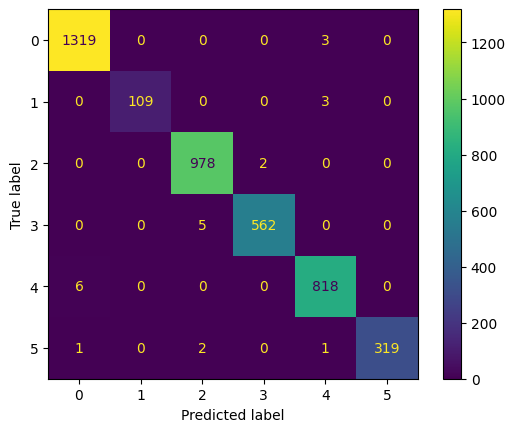

In [8]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Optimización del modelo con `GridSearch`

### Parámetros para la cuadrícula

In [ ]:
param_grid = {'n_neighbors': [3, 5, 10, 15, 30, 50],
              'weights': ['uniform', 'distance'],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'metric': ['cityblock', 'cosine', 'euclidean', 'haversine', 'l1', 'l2', 'manhattan', 'nan_euclidean']
              }
random_search = RandomizedSearchCV(estimator=knn_model,
                                   param_distributions=param_grid,
                                   cv=5,
                                   refit='accuracy'
                                   )
                                    


### Entrenamiento de la cuadrícula

In [58]:
random_search.fit(X_train, y_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self

,estimator,KNeighborsClassifier()
,param_distributions,"{'algorithm': ['auto', 'ball_tree', ...], 'metric': ['cityblock', 'cosine', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,'accuracy'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


### Mejores párametros

In [59]:
random_search.best_params_

{'weights': 'distance',
 'n_neighbors': 30,
 'metric': 'cityblock',
 'algorithm': 'ball_tree'}

In [60]:
grid_knn = random_search.best_estimator_
y_pred_test = grid_knn.predict(X_test)
y_pred_train = grid_knn.predict(X_train)

### Métricas de la cuadrícula

In [61]:
accuracy_score(y_test, y_pred_test)

0.8856589147286822

In [62]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.50      0.02      0.03       266
           1       0.86      0.99      0.92      1773
           2       0.89      0.77      0.82       604
           3       0.00      0.00      0.00        19
           4       0.92      0.98      0.95      1466

    accuracy                           0.89      4128
   macro avg       0.63      0.55      0.54      4128
weighted avg       0.86      0.89      0.85      4128



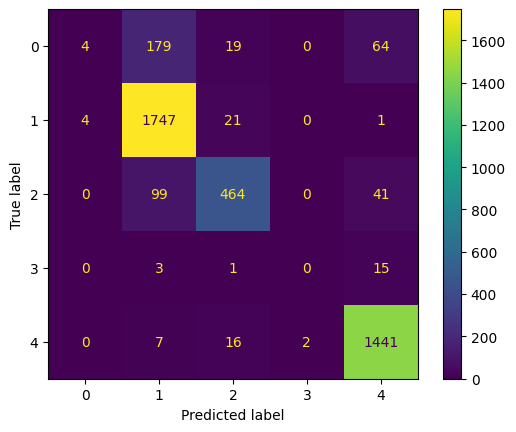

In [63]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### Probamos con diferentes valores de k

In [ ]:
acurracy = []
for k in range(1, 21):
    knn_model_optimus = KNeighborsClassifier(n_neighbors=k, weights='distance', algorithm='auto', metric='cityblock', n_jobs=-1)
    knn_model_optimus.fit(X_train, y_train)
    y_pred_test = knn_model_optimus.predict(X_test)
    y_pred_train = knn_model_optimus.predict(X_train)
    acurracy.append(accuracy_score(y_test, y_pred_test))

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change t

In [74]:
acurracy

[0.8473837209302325,
 0.8473837209302325,
 0.8694282945736435,
 0.8728197674418605,
 0.8788759689922481,
 0.8825096899224806,
 0.8854166666666666,
 0.8849321705426356,
 0.8856589147286822,
 0.8868701550387597,
 0.8861434108527132,
 0.8863856589147286,
 0.8849321705426356,
 0.8859011627906976,
 0.8854166666666666,
 0.8866279069767442,
 0.8851744186046512,
 0.8866279069767442,
 0.8873546511627907,
 0.8868701550387597]

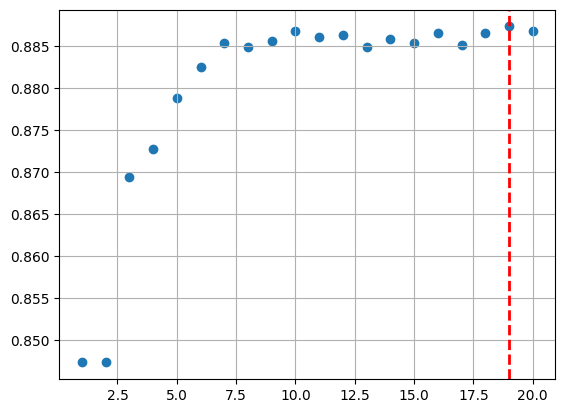

In [75]:
k = np.arange(1, 21)
plt.scatter(x=k, y=acurracy)
plt.axvline(x=19, color='red', linestyle='--', linewidth=2)
plt.grid()
plt.show()

### Observamos que el valor de máximo accuracy lo obtenemos para k=19, con el resto de parámetros fijados

In [ ]:
knn_model_optimus = KNeighborsClassifier(n_neighbors=19, weights='distance', algorithm='auto', metric='cityblock', n_jobs=-1)
knn_model_optimus.fit(X_train, y_train)
y_pred_test = knn_model_optimus.predict(X_test)
y_pred_train = knn_model_optimus.predict(X_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [71]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.42      0.04      0.07       266
           1       0.86      0.98      0.92      1773
           2       0.88      0.78      0.83       604
           3       0.00      0.00      0.00        19
           4       0.93      0.98      0.95      1466

    accuracy                           0.89      4128
   macro avg       0.62      0.56      0.55      4128
weighted avg       0.86      0.89      0.86      4128



## Conclusiones

>- Parece que el conjunto de datos esta sesgado hacia la clase media(1), podemos redistribuir los datos para tener mejores predicciones en el resto de clases
>- Al optimizar, el modelo mejora en precision y recall para la clase 2 cuanto mayor es "K", no mejora para la clase 0. Seguramente se debe a la distribución de la variable 'label'
>- Podemos decir que el modelo es bueno pero no suficiente

## Guardado de modelos

In [ ]:
model = knn_model
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelo-knn-kmeans.pkl', 'wb') as file:
    pickle.dump(model, file)